# Smart City Air Quality: Exploratory Data Analysis (EDA)
**Objective:** Menganalisis data telemetri, memverifikasi korelasi antara faktor cuaca dan metrik polusi udara, serta mengonfirmasi anomali secara visual untuk menyiapkan fitur terbaik sebelum melatih model.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur gaya grafik agar visualisasi lebih bersih dan rapi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Memuat dataset sintetis yang telah digenerate sebelumnya
df = pd.read_csv('data/smartcity_telemetry.csv')

# Mengonversi kolom recorded_at menjadi objek datetime untuk pemrosesan kronologis
df['recorded_at'] = pd.to_datetime(df['recorded_at'])
print(f"Ukuran Dataset: {df.shape}")
df.head()

Ukuran Dataset: (5500, 12)


,timestamp,zone,pm25,pm10,no2,co,o3,temperature,humidity,wind_speed,wind_direction,ground_truth_anomaly
0,2026-06-14 14:44:40,Jakarta Selatan,32,51,23,0.50,49,26.7,78.0,0.4,20,0
1,2026-06-14 14:14:40,Jakarta Barat,12,14,26,0.91,37,34.4,90.4,0.0,8,0
2,2026-06-14 13:44:40,Jakarta Selatan,27,43,15,0.41,42,28.4,76.0,2.3,61,0
3,2026-06-14 13:14:40,Jakarta Timur,82,107,28,0.98,46,29.3,78.9,2.7,112,0
4,2026-06-14 12:44:40,Jakarta Selatan,27,36,25,0.35,46,29.7,72.0,1.2,97,0


In [14]:
# Memeriksa kesehatan data, tipe data, dan memastikan tidak ada nilai kosong (null) yang tidak diinginkan
print("--- Informasi Data ---")
df.info()

print("\n--- Statistik Deskriptif ---")
df.describe().T

--- Informasi Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   timestamp             5500 non-null   datetime64[ns]
 1   zone                  5500 non-null   object        
 2   pm25                  5500 non-null   int64         
 3   pm10                  5500 non-null   int64         
 4   no2                   5500 non-null   int64         
 5   co                    5500 non-null   float64       
 6   o3                    5500 non-null   int64         
 7   temperature           5500 non-null   float64       
 8   humidity              5500 non-null   float64       
 9   wind_speed            5500 non-null   float64       
 10  wind_direction        5500 non-null   int64         
 11  ground_truth_anomaly  5500 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(6), object(1)

,count,mean,min,25%,50%,75%,max,std
timestamp,5500,2026-04-18 07:59:40.000000256,2026-02-20 01:14:40,2026-03-20 16:37:10,2026-04-18 07:59:40,2026-05-16 23:22:10,2026-06-14 14:44:40,NaN
pm25,5500.0,42.242727,0.0,26.0,39.0,52.0,227.0,27.785055
pm10,5500.0,62.216909,0.0,38.0,58.0,78.0,321.0,38.566112
no2,5500.0,17.604545,0.0,12.0,18.0,23.0,48.0,8.691254
co,5500.0,0.8421,0.0,0.52,0.75,0.99,5.17,0.679212
o3,5500.0,43.874727,0.0,36.0,45.0,53.0,86.0,13.705464
temperature,5500.0,30.015236,18.9,28.0,30.0,32.1,40.0,3.02351
humidity,5500.0,74.829236,37.0,68.175,75.0,81.2,100.0,9.691717
wind_speed,5500.0,2.506455,0.0,0.7,1.7,3.5,21.4,2.517375
wind_direction,5500.0,178.006,0.0,91.0,178.0,266.0,359.0,102.364807


## 1. Profil Distribusi Polutan & Cuaca


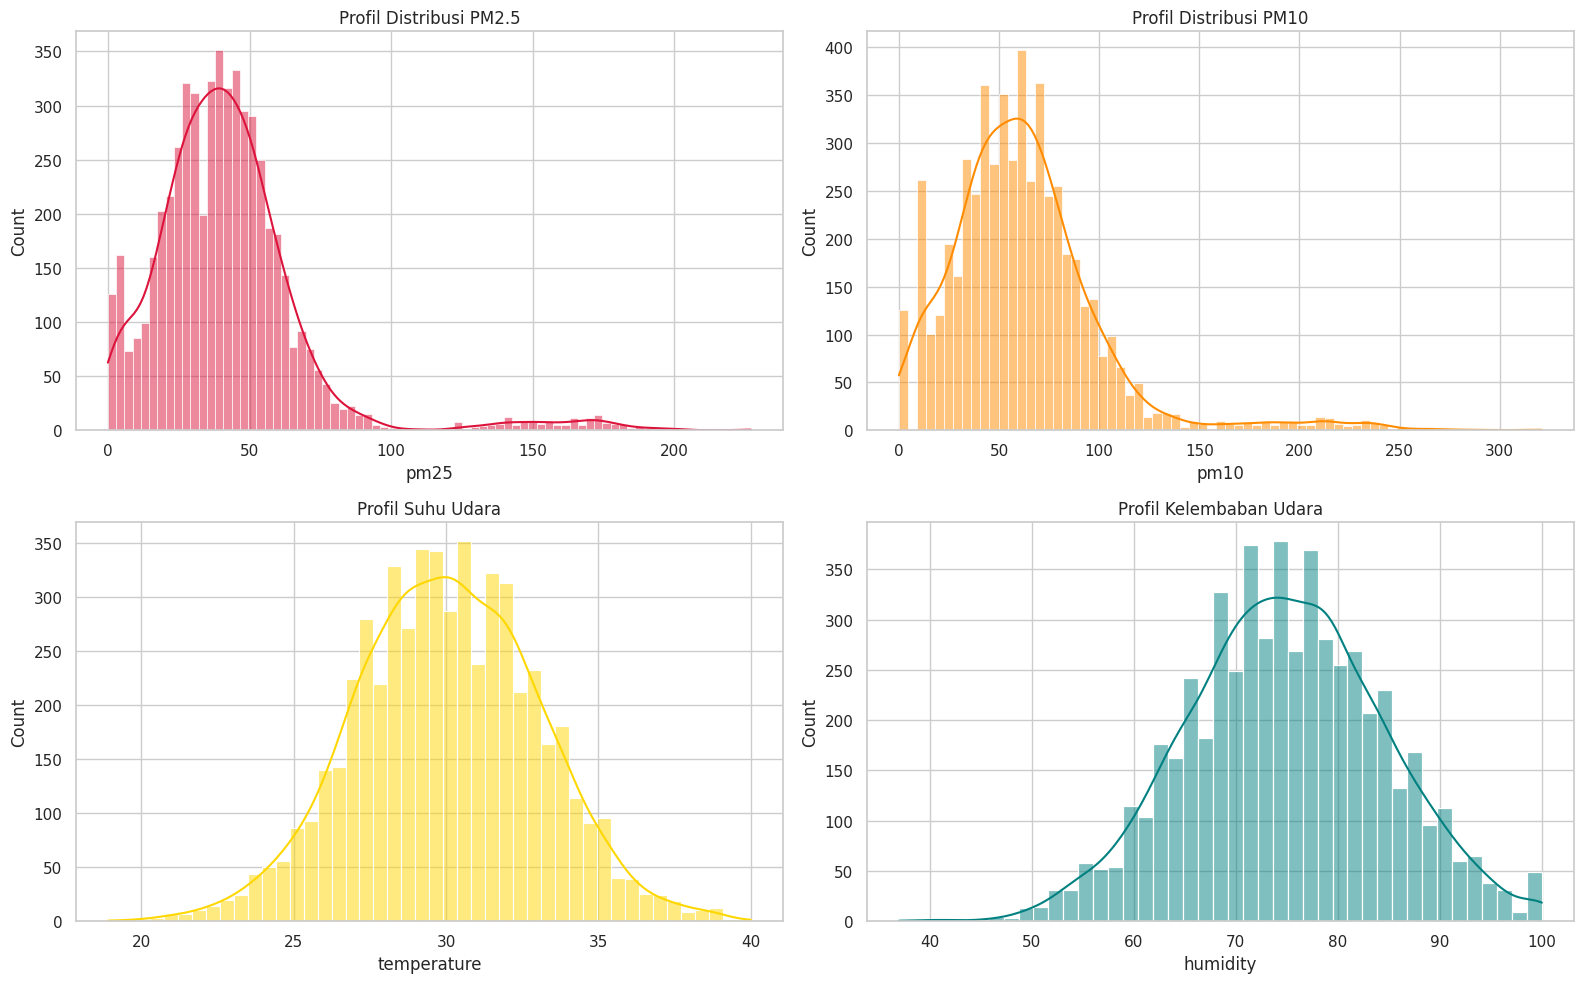

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Distribusi PM2.5
sns.histplot(df['pm25'], kde=True, ax=axes[0, 0], color='crimson')
axes[0, 0].set_title('Profil Distribusi PM2.5')

# Distribusi PM10
sns.histplot(df['pm10'], kde=True, ax=axes[0, 1], color='darkorange')
axes[0, 1].set_title('Profil Distribusi PM10')

# Distribusi Suhu (Konteks Iklim Tropis Jakarta)
sns.histplot(df['temperature'], kde=True, ax=axes[1, 0], color='gold')
axes[1, 0].set_title('Profil Suhu Udara')

# Distribusi Kelembaban
sns.histplot(df['humidity'], kde=True, ax=axes[1, 1], color='teal')
axes[1, 1].set_title('Profil Kelembaban Udara')

plt.tight_layout()
plt.show()

## 2. Matriks Korelasi: Pengaruh Cuaca Terhadap Polusi

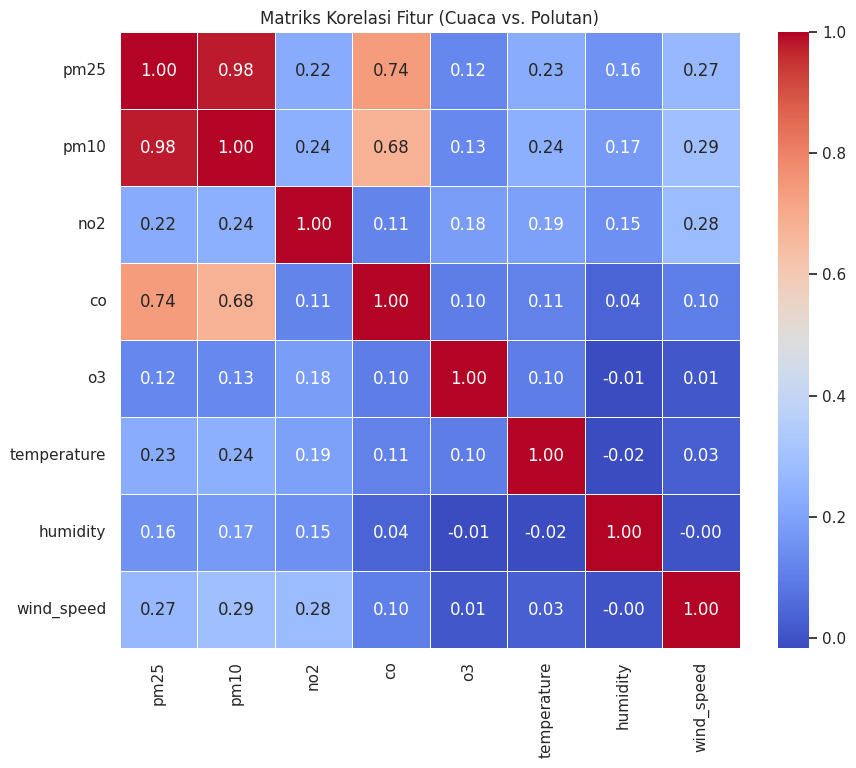

In [16]:
# Mengisolasi kolom numerik untuk perhitungan matriks korelasi
numeric_cols = ['pm25', 'pm10', 'no2', 'co', 'o3', 'temperature', 'humidity', 'wind_speed']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriks Korelasi Fitur (Cuaca vs. Polutan)')
plt.show()

## 3. Analisis Spasial: Tingkat Polusi di Lima Wilayah Jakarta

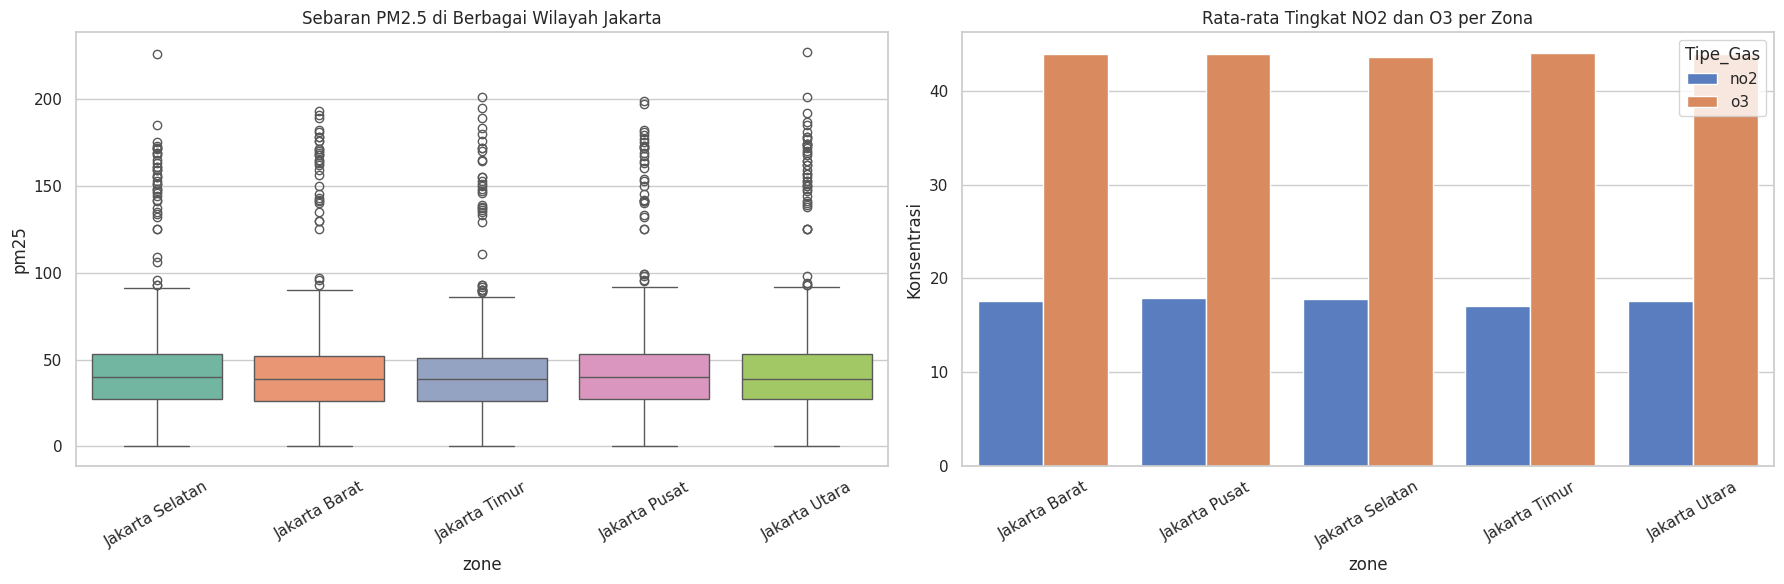

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Boxplot untuk variasi PM2.5 di 5 wilayah Jakarta
# Menggunakan hue='zone' dan legend=False untuk menghilangkan warning FutureWarning
sns.boxplot(data=df, x='zone', y='pm25', ax=axes[0], hue='zone', palette='Set2', legend=False)
axes[0].set_title('Sebaran PM2.5 di Berbagai Wilayah Jakarta')
# Menggunakan set_xticks sebelum set_xticklabels untuk menghilangkan UserWarning
axes[0].set_xticks(range(len(df['zone'].unique())))
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30)

# Rata-rata polusi gas (NO2 dan O3) per wilayah
zone_gases = df.groupby('zone')[['no2', 'o3']].mean().reset_index()
zone_gases_melted = pd.melt(zone_gases, id_vars=['zone'], value_vars=['no2', 'o3'],
                            var_name='Tipe_Gas', value_name='Konsentrasi')

sns.barplot(data=zone_gases_melted, x='zone', y='Konsentrasi', hue='Tipe_Gas', ax=axes[1], palette='muted')
axes[1].set_title('Rata-rata Tingkat NO2 dan O3 per Zona')
axes[1].set_xticks(range(len(df['zone'].unique())))
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30)

plt.tight_layout()
plt.show()

## 4. Identifikasi Profil Anomali data

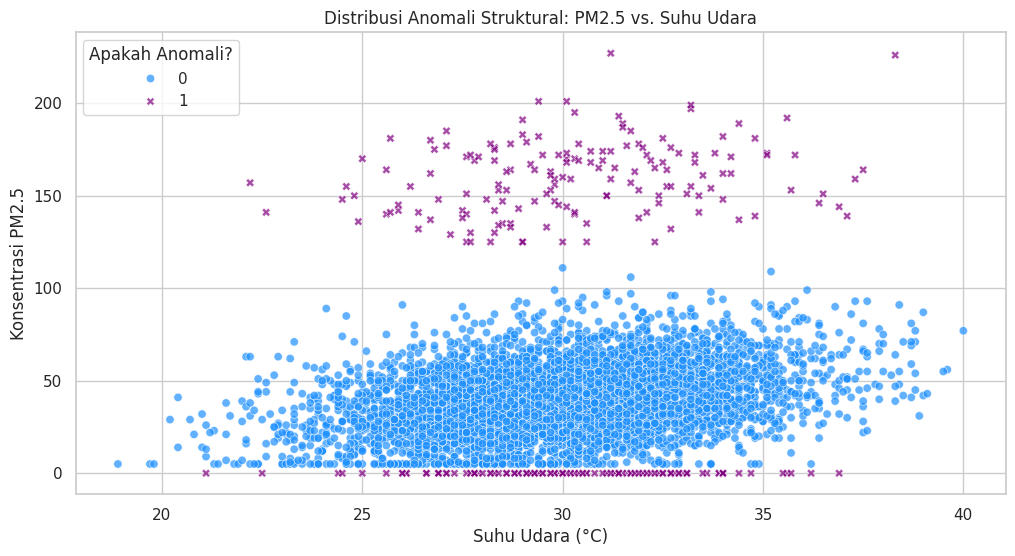

Total Anomali yang Dimasukkan: 287 data dari 5500 total baris


In [18]:
plt.figure(figsize=(12, 6))

# Scatter plot PM2.5 vs Suhu, dengan warna pembeda untuk data anomali (ground truth)
sns.scatterplot(
    data=df,
    x='temperature',
    y='pm25',
    hue='ground_truth_anomaly',
    palette={0: 'dodgerblue', 1: 'purple'},
    alpha=0.7,
    style='ground_truth_anomaly',
    markers={0: 'o', 1: 'X'}
)

plt.title('Distribusi Anomali Struktural: PM2.5 vs. Suhu Udara')
plt.xlabel('Suhu Udara (°C)')
plt.ylabel('Konsentrasi PM2.5')
plt.legend(title='Apakah Anomali?')
plt.show()

print(f"Total Anomali yang Dimasukkan: {df['ground_truth_anomaly'].sum()} data dari {len(df)} total baris")